In [173]:
#I want to be able to take a all the data for a given cell and temperature and retrieve a dataset of densities and the detunings they were measured at. 
#data should be returned in an array of points (detuning, density)

In [2]:
#All my imports go here
import pandas as pd
import numpy as np

from density_app.functions.data_files import batchProcessFiles, file_path_traverse
from fnmatch import fnmatch
from density_app.functions.fitting_and_error import linear_fit_data_with_error, density_error, get_parabolic_fit, get_parabola_extrema, get_density_error_from_parabolic_fit, get_extended_xs
from density_app.functions.alkali_density_calculation import get_main_prefactor, get_first_order_terms_prefactor, get_second_order_terms_prefactor, get_first_order_terms, get_second_order_terms, rb_density_second_order
from density_app.functions.formatting import formatter
from density_app.functions.conversions import convertTtoKelvin

import matplotlib.pyplot as plt

#from density_app.functions.constants import LIGHT_SPEED

In [3]:
#This module takes a root directory, finds all the data files and experiment settings files and creates a processed data file for each data set

path = "/Users/eleanor/Desktop/Data4Eleanor/Test"
batchProcessFiles(path) #creates processed files if none exist for a given raw data file contained within the directory located at path

unable to create processed file for  /Users/eleanor/Desktop/Data4Eleanor/Test/80C_779.935nm/2024-09-13
unable to create processed file for  /Users/eleanor/Desktop/Data4Eleanor/Test/90C_779.758nm/2024-09-23
unable to create processed file for  /Users/eleanor/Desktop/Data4Eleanor/Test/80C_779.955nm/2024-09-13


In [4]:
#This module is creating the dataset of densities and corresponding detunings

#THIS IS FOR CELL 314A
cell = '314A'
d2_orig = 7.80034e-5
d2_adjust = -0.00005e-5
d1_resonance = 7.94768e-5 #cm
d2_resonance = d2_orig+d2_adjust #cm
optical_path = 3.7 #cm

wl_error = 0.00003e-5
d2_error = 0#.00003e-5
d1_error = 0#.00003e-5

length = 3.7
length_error = 0.005


def get_density_vs_probe(root):
    data_file_str = '*_processed*'
    experiment_file_str = '*Experiment_Params*' 
    #traverse the root directory to collect wavelengths
    #get list of all csv files
    files = file_path_traverse(root)
    density_data = pd.DataFrame({'ProbeWavelength':[], 'Density':[], 'DensityError':[]})

    for key, value in files.items():
            #for each key I need to create one processed file
            processed = ''
            exp = ''
            #experiment_params = {}
            for v in value:
                if fnmatch(v, data_file_str):
                    processed = v #locates the data file in the set of files indexed under the current key
                if fnmatch(v, experiment_file_str):
                    exp = v #locates the data file in the set of files indexed under the current key
                #processed_data = pd.read_csv(processed)
            experiment_params = pd.read_csv(exp)
            probe_wavelength = (experiment_params['LaserWavelength'].to_numpy()[0]*10**(-7))
            temperature = experiment_params['OvenTemperature'].to_numpy()[0]
            #get the magnetic field data (x), the rotations (y) and the error from the data file
            data = pd.read_csv(processed)
            #convert to density values
            x = data['Magnetic Field (Gauss)'].to_numpy()
            y = data['Rotation (Radians)'].to_numpy()
            error = data['Rotation Standard Deviation'].to_numpy()
            param, cov = linear_fit_data_with_error(x,y,error)
            slope = param[0]
            slope_error = np.sqrt(cov[0][0])
            #put it in a dataframe
            #calculate error 
            rb_density = rb_density_second_order(d1_resonance, d2_resonance, optical_path, probe_wavelength, temperature, slope)
            total_error = np.sqrt(((wl_error+d2_error)/(d2_resonance-probe_wavelength))**2+(slope_error/slope)**2+((wl_error+d1_error)/(d1_resonance-probe_wavelength))**2)*rb_density
            total_error2 = density_error(slope_error, slope, length_error, length, wl_error, probe_wavelength, d1_error, d1_resonance, d2_error, d2_resonance, temperature)
            new_row = pd.DataFrame({'ProbeWavelength':[probe_wavelength], 'Density': [rb_density], 'DensityError':[total_error2], 'PercentError':[(total_error2/rb_density)*100]})
            density_data = pd.concat([density_data, new_row], ignore_index=True) 
        
    return density_data

def get_true_density(data_set, d2_res):
    x = data_set['ProbeWavelength'].to_numpy()
    y = data_set['Density'].to_numpy()
    error = data_set['DensityError'].to_numpy()
    my_fit, cv = get_parabolic_fit(x, y, error)
    #get the true density value by taking the minimum of my fit
    min_wl, min_den = get_parabola_extrema(my_fit)
    rb_den_final_error = get_density_error_from_parabolic_fit(cv)
    return my_fit, min_den, rb_den_final_error

def get_data(data_set):
    x = data_set['ProbeWavelength'].to_numpy()
    y = data_set['Density'].to_numpy()
    error = data_set['DensityError'].to_numpy()
    return x,y,error
     

def get_dataset(temp):
    dir = '/Users/eleanor/Desktop/Data4Eleanor/' + f"{temp}"+"C"
    
         
    

dir_80 = '/Users/eleanor/Desktop/Data4Eleanor/80C'
dir_90 = '/Users/eleanor/Desktop/Data4Eleanor/90C'
dir_110 = '/Users/eleanor/Desktop/Data4Eleanor/110C'
dir_120 = '/Users/eleanor/Desktop/Data4Eleanor/120C'

density_80C = get_density_vs_probe(dir_80)
density_90C = get_density_vs_probe(dir_90)
density_110C = get_density_vs_probe(dir_110)
density_120C = get_density_vs_probe(dir_120)

#print(density_120C)
#print(density_120C['ProbeWavelength'].to_numpy())

          2
3.42e+19 x - 1.297e+14 x + 1.624e+12
[[ 3.19787098e+36 -3.52474341e+30 -7.79733728e+28]
 [-3.52474341e+30  7.44048477e+28  1.15828052e+24]
 [-7.79733728e+28  1.15828052e+24  3.71414645e+21]]
60943797481.24713


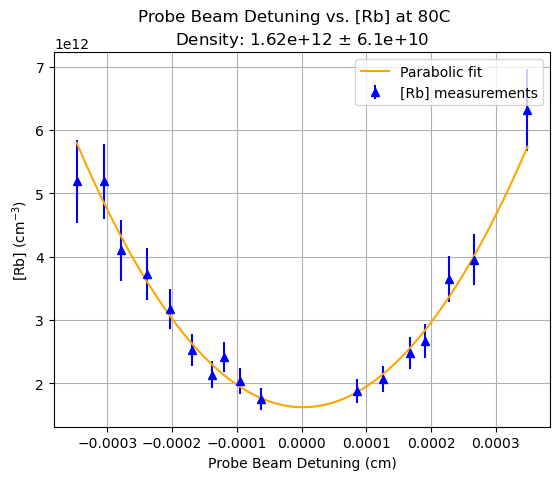

In [8]:
#Plot stuff

from density_app.functions.fitting_and_error import get_extended_xs, get_parabolic_fit, get_parabola_extrema, get_density_error_from_parabolic_fit
from density_app.functions.alkali_density_calculation import get_main_prefactor, get_first_order_terms_prefactor, get_second_order_terms_prefactor, get_first_order_terms, get_second_order_terms, killian_density

def plot_parabola(data_set, d2_resonance, temperature):
    x = (data_set['ProbeWavelength'].to_numpy()-d2_resonance)/data_set['ProbeWavelength'].to_numpy()
    y = data_set['Density'].to_numpy()
    error = data_set['DensityError'].to_numpy()

    #figure setup
    fig = plt.figure()
    ax = fig.add_subplot()
    fig.subplots_adjust(top=0.89)

    my_fit, cv = get_parabolic_fit(x, y, error)

    #plot the data sets
    ax.errorbar(x=x, y=y, yerr=abs(error), color='blue', marker='^', linestyle='none', label = '[Rb] measurements')
    #plot the parabolic fit
    polyline = get_extended_xs(x, 100, .0001)
    ax.plot(polyline, my_fit(polyline), color='orange', label = 'Parabolic fit') 

    #get the true density value by taking the minimum of my fit
    min_wl, min_den = get_parabola_extrema(my_fit)
    min_density_fmt = formatter(min_den, 2)
    rb_den_final_error = get_density_error_from_parabolic_fit(cv)
    rb_den_final_error_fmt = formatter(rb_den_final_error, 1)
    den_text = "Density: "+min_density_fmt+r" $ \pm $ "+rb_den_final_error_fmt

    #set up labels, titles, grid
    fig.suptitle("Probe Beam Detuning vs. [Rb] at %dC"%(temperature))
    ax.set_title(den_text)
    ax.legend()
    ax.set_xlabel("Probe Beam Detuning (cm)")
    ax.set_ylabel("[Rb] (cm$^{-3}$)")
    ax.grid(visible=True, which='both', axis='both')

    #Print out Density info, for easy copypasting if necessary
    #print("Alkali Metal Density: ", min_density_fmt)
    #print("Density Error: ", rb_den_final_error_fmt)
    print(my_fit)
    print(cv)
    print(rb_den_final_error)
    #display the plot
    plt.show()

#actual density should be a flat line at the minimum
#want to know the difference between the fit and the minimum and also the points and the minimum

T=80
data = density_80C
plot_parabola(data, d2_resonance, T)

#fit, rb, err = get_true_density(data, d2_resonance)
#print("[Rb]: ", rb)
#print("Precent Error:", err*100/rb)
#print("Verdet adjustment: ", get_verdet_adjustment(data, d1_resonance, d2_resonance, 3.7, T))
#print("Killian: ",killian_density(T))

<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\c'
/var/folders/jz/gs4_jj7s0wjdn4knc7gw58lh0000gn/T/ipykernel_99762/2639512929.py:37: SyntaxWarning: invalid escape sequence '\c'
  ax.errorbar(x=x80, y=y80, yerr=abs(error80), color='blue', marker='o', linestyle='none', label = '[Rb] at $80^{\circ}$C')
/var/folders/jz/gs4_jj7s0wjdn4knc7gw58lh0000gn/T/ipykernel_99762/2639512929.py:38: SyntaxWarning: invalid escape sequence '\c'
  ax.errorbar(x=x90, y=y90, yerr=abs(error90), color='orange', marker='^', linestyle='none', label = '[Rb] at $90^{\circ}$C')
/var/folders/jz/gs4_jj7s0wjdn4knc7gw58lh0000gn/T/ipykernel_99762/2639512929.py:39: Synta

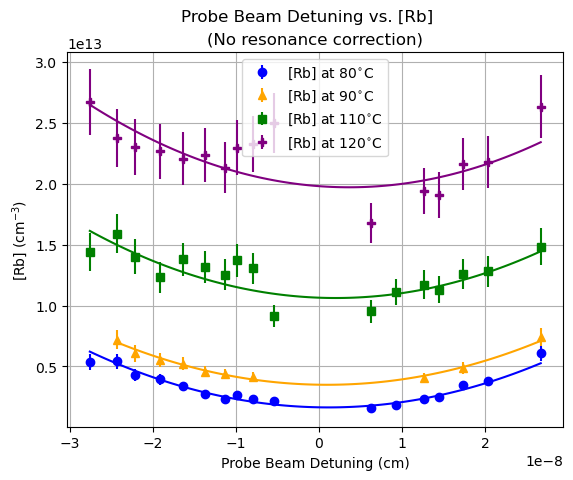

In [217]:
#Plot stuff - this version plots as a function of detuning

from density_app.functions.fitting_and_error import get_extended_xs, get_parabolic_fit, get_parabola_extrema, get_density_error_from_parabolic_fit
from density_app.functions.alkali_density_calculation import get_main_prefactor, get_first_order_terms_prefactor, get_second_order_terms_prefactor, get_first_order_terms, get_second_order_terms, killian_density




x80 = density_80C['ProbeWavelength'].to_numpy()-d2_resonance
y80 = density_80C['Density'].to_numpy()
error80 = density_80C['DensityError'].to_numpy()

x90 = density_90C['ProbeWavelength'].to_numpy()-d2_resonance
y90 = density_90C['Density'].to_numpy()
error90 = density_90C['DensityError'].to_numpy()

x110 = density_110C['ProbeWavelength'].to_numpy()-d2_resonance
y110 = density_110C['Density'].to_numpy()
error110 = density_110C['DensityError'].to_numpy()

x120 = density_120C['ProbeWavelength'].to_numpy()-d2_resonance
y120 = density_120C['Density'].to_numpy()
error120 = density_120C['DensityError'].to_numpy()

my_fit80, cv80 = get_parabolic_fit(x80, y80, error80)
my_fit90, cv90 = get_parabolic_fit(x90, y90, error90)
my_fit110, cv110 = get_parabolic_fit(x110, y110, error110)
my_fit120, cv120 = get_parabolic_fit(x120, y120, error120)

#figure setup
fig = plt.figure()
ax = fig.add_subplot()
fig.subplots_adjust(top=0.89)


#plot the data sets
ax.errorbar(x=x80, y=y80, yerr=abs(error80), color='blue', marker='o', linestyle='none', label = '[Rb] at $80^{\circ}$C')
ax.errorbar(x=x90, y=y90, yerr=abs(error90), color='orange', marker='^', linestyle='none', label = '[Rb] at $90^{\circ}$C')
ax.errorbar(x=x110, y=y110, yerr=abs(error110), color='green', marker='s', linestyle='none', label = '[Rb] at $110^{\circ}$C')
ax.errorbar(x=x120, y=y120, yerr=abs(error120), color='purple', marker='P', linestyle='none', label = '[Rb] at $120^{\circ}$C')

#plot the parabolic fit
polyline80 = get_extended_xs(x80, 100, .0001)
polyline90 = get_extended_xs(x90, 100, .0001)
polyline110 = get_extended_xs(x110, 100, .0001)
polyline120 = get_extended_xs(x120, 100, .0001)

ax.plot(polyline80, my_fit80(polyline80), color='blue') 
ax.plot(polyline90, my_fit90(polyline90), color='orange') 
ax.plot(polyline110, my_fit110(polyline110), color='green') 
ax.plot(polyline120, my_fit120(polyline120), color='purple') 


#get the true density value by taking the minimum of my fit
#min_wl, min_den = get_parabola_extrema(my_fit)
#min_density_fmt = formatter(min_den, 2)
#rb_den_final_error = get_density_error_from_parabolic_fit(cv)
#rb_den_final_error_fmt = formatter(rb_den_final_error, 1)
#den_text = "Density: "+min_density_fmt+r" $ \pm $ "+rb_den_final_error_fmt

#set up labels, titles, grid
fig.suptitle("Probe Beam Detuning vs. [Rb]")
ax.set_title("(No resonance correction)")
ax.legend(loc='best')
ax.set_xlabel("Probe Beam Detuning (cm)")
ax.set_ylabel("[Rb] (cm$^{-3}$)")
ax.grid(visible=True, which='both', axis='both')


#display the plot
plt.show()

#actual density should be a flat line at the minimum
#want to know the difference between the fit and the minimum and also the points and the minimum





In [ ]:
from density_app.functions.constants import LIGHT_SPEED, PLANKS_CONSTANT, ELECTRON_MASS, ELECTRON_CHARGE, BOHR_MAGNETON, BOLTZMANN_CONSTANT

c = LIGHT_SPEED
h = PLANKS_CONSTANT
m = ELECTRON_MASS
q = ELECTRON_CHARGE
u = BOHR_MAGNETON
k = BOLTZMANN_CONSTANT

#parabola coefficients
a2 = 5.885e+27
a1 = -9.181e+23 
a0 = 3.581e+19

        
#cell info
#THIS IS FOR CELL 314A
cell = '314A'
d2_orig = 7.80034e-5
d2_adjust = -0.00009e-5
d1_resonance = 7.94768e-5 #cm
d2_resonance = d2_orig+d2_adjust #cm
optical_path = 3.7 #cm
wl_error = 0.00003e-5
d2_error = 0#.00003e-5
d1_error = 0#.00003e-5
length = 3.7
length_error = 0#.005

T = 80

def detuning_term(opt_path, probe, d1, d2, temp):
    coeff0 = (opt_path*ELECTRON_CHARGE**2*BOHR_MAGNETON)/(6*ELECTRON_MASS*PLANKS_CONSTANT*LIGHT_SPEED)
    coeff1 = probe**2/(3*LIGHT_SPEED**2)
    coeff2 = (PLANKS_CONSTANT*probe)/(LIGHT_SPEED*BOLTZMANN_CONSTANT*convertTtoKelvin(temp))
    term1 = ((4*d1**2)/(d1-probe)**2) + ((7*d2**2)/(d2-probe)**2) - ((2*d1*d2)/((d1-probe)*(d2-probe)))
    term2 = (d1/(d1-probe))-(d2/(d2-probe))

    f = coeff0*(coeff1*term1 - coeff2*term2)
    return f


def effective_density(a2, a1, a0, x):
    den = a1*x**2 + a2*x + a0
    return den

density = effective_density(a2, a1, a0, d2_resonance)
print(density)
wavelengths = density_80C['ProbeWavelength'].to_numpy()
fs = detuning_term(optical_path, wavelengths, d1_resonance, d2_resonance, T)
predicted_effective_den = effective_density(a2,a1,a0,wavelengths)


diff = predicted_effective_den-density
print(detunings)
print(predicted_effective_den)
VL = diff/fs
print(VL)



4.590805169139216e+23
[-1.82e-08  2.12e-08 -2.67e-08  1.02e-08 -1.04e-08  1.35e-08 -9.00e-09
  2.76e-08  7.10e-09 -1.55e-08 -1.28e-08 -7.00e-09 -4.50e-09 -2.34e-08
  1.53e-08  1.82e-08 -2.13e-08]
[4.58973410e+23 4.59205279e+23 4.58923387e+23 4.59140544e+23
 4.59019313e+23 4.59159964e+23 4.59027552e+23 4.59242943e+23
 4.59122300e+23 4.58989299e+23 4.59005189e+23 4.59039322e+23
 4.59054034e+23 4.58942808e+23 4.59170557e+23 4.59187624e+23
 4.58955166e+23]
[-5.05652032e+37  8.01170873e+37 -1.59552273e+38  8.91754774e+36
 -9.44003111e+36  2.06790460e+37 -6.11846062e+36  1.76844821e+38
  3.00703808e+36 -3.12403198e+37 -1.75967251e+37 -2.87916847e+36
 -7.65036953e+35 -1.07429204e+38  3.01056886e+37  5.06826986e+37
 -8.10363506e+37]


In [258]:
print(formatter(killian_density(130), 3))
T=130
#a = f"{T}"+"C"
#print(a)

3.591e+13


80:  1.79e+12 2.6e+11
90:  2.78e+12 2.5e+11
110:  8.26e+12 8.6e+11
120:  1.47e+13 7.0e+11


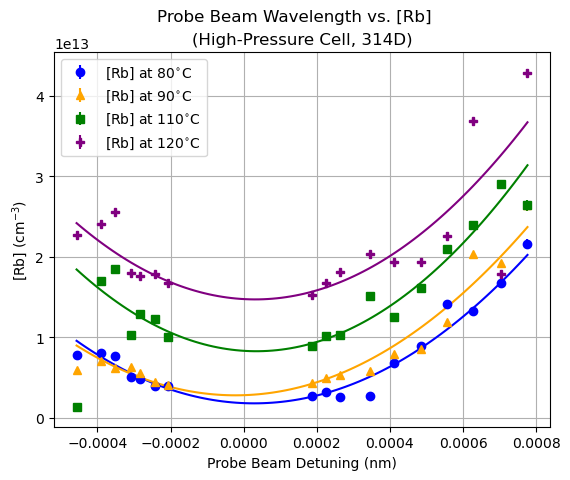

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from density_app.functions.fitting_and_error import get_extended_xs, get_parabolic_fit, get_parabola_extrema, get_density_error_from_parabolic_fit
from density_app.functions.formatting import formatter

import warnings
warnings.filterwarnings('ignore')

#High pressure cell data analysis
#Cell: 314D

#file paths
fp_80 = "/Users/eleanor/Desktop/development/alkali_density/alkali-density/high_pressure_cell/314D_80.csv"
fp_90 = "/Users/eleanor/Desktop/development/alkali_density/alkali-density/high_pressure_cell/314D_90.csv"
fp_100 = "/Users/eleanor/Desktop/development/alkali_density/alkali-density/high_pressure_cell/314D_100.csv"
fp_110 = "/Users/eleanor/Desktop/development/alkali_density/alkali-density/high_pressure_cell/314D_110.csv"
fp_120 = "/Users/eleanor/Desktop/development/alkali_density/alkali-density/high_pressure_cell/314D_120.csv"
fp_130 = "/Users/eleanor/Desktop/development/alkali_density/alkali-density/high_pressure_cell/314D_130.csv"

#Cell data for 314D
#Total Pressure: 1633.1 +/- 0.1 milliamagat
#Xe Pressure: 51.2 +/- 0.1 milliamagat
#N Pressure: 
#He Pressure: 
d2 = 780.0323

def get_hp_data(fp):
    data = pd.read_csv(fp)
    x = (data['Wavelength (nm)'].to_numpy()-d2)/data['Wavelength (nm)']
    x_err = data['Wavelength Error (nm)'].to_numpy()
    y = data['[Rb] (cm^-3)'].to_numpy()
    y_err = data['[Rb] Error (cm^-3)'].to_numpy()

    return x, x_err, y, y_err

def get_density(my_fit, cv):
   #get the true density value by taking the minimum of my fit
    min_wl, min_den = get_parabola_extrema(my_fit)
    min_density_fmt = formatter(min_den, 2)
    rb_den_final_error = get_density_error_from_parabolic_fit(cv)
    rb_den_final_error_fmt = formatter(rb_den_final_error, 1)
    #den_text = "Density: "+min_density_fmt+r" $ \pm $ "+rb_den_final_error_fmt
    return min_density_fmt,rb_den_final_error_fmt
    
x80, xerr80, y80, yerr80 = get_hp_data(fp_80)
x90, xerr90, y90, yerr90 = get_hp_data(fp_90)
x100, xerr100, y100, yerr100 = get_hp_data(fp_100)
x110, xerr110, y110, yerr110 = get_hp_data(fp_110)
x120, xerr120, y120, yerr120 = get_hp_data(fp_120)
x130, xerr130, y130, yerr130 = get_hp_data(fp_130)

#figure setup
fig = plt.figure()
ax = fig.add_subplot()
fig.subplots_adjust(top=0.89)

my_fit80, cv80 = get_parabolic_fit(x80, y80, yerr80)
my_fit90, cv90 = get_parabolic_fit(x90, y90, yerr90)
my_fit90, cv90 = get_parabolic_fit(x90, y90, yerr90)
my_fit100, cv100 = get_parabolic_fit(x100, y100, yerr100)
my_fit110, cv110 = get_parabolic_fit(x110, y110, yerr110)
my_fit120, cv120 = get_parabolic_fit(x120, y120, yerr120)
my_fit130, cv130 = get_parabolic_fit(x130, y130, yerr130)


#get the miniumum density values
den80, den80_err = get_density(my_fit80, cv80)
den90, den90_err = get_density(my_fit90, cv90)
#den100, den100_err = get_density(my_fit100, cv100)
den110, den110_err = get_density(my_fit110, cv110)
den120, den120_err = get_density(my_fit120, cv120)
#den130, den130_err = get_density(my_fit130, cv130)

print("80: ", den80, den80_err)
print("90: ", den90, den90_err)
#print("100: ", den100, den100_err)
print("110: ", den110, den110_err)
print("120: ", den120, den120_err)
#print("130: ", den130, den130_err)

#print(np.diagonal(cv))

#plot the data sets
ax.errorbar(x=x80, y=y80, yerr=yerr80, color='blue', marker='o', linestyle='none', label = '[Rb] at $80^{\circ}$C')
ax.errorbar(x=x90, y=y90, yerr=yerr90, color='orange', marker='^', linestyle='none', label = '[Rb] at $90^{\circ}$C')
#ax.errorbar(x=x100, y=y100, yerr=yerr100, color='yellow', marker='s', linestyle='none', label = '[Rb] at $100^{\circ}$C')
ax.errorbar(x=x110, y=y110, yerr=yerr110, color='green', marker='s', linestyle='none', label = '[Rb] at $110^{\circ}$C')
ax.errorbar(x=x120, y=y120, yerr=yerr120, color='purple', marker='P', linestyle='none', label = '[Rb] at $120^{\circ}$C')
#ax.errorbar(x=x130, y=y130, yerr=yerr130, color='purple', marker='h', linestyle='none', label = '[Rb] at $130^{\circ}$C')
#plot the parabolic fit
polyline80 = get_extended_xs(x80, 100, .0001)
polyline90 = get_extended_xs(x90, 100, .0001)
polyline100 = get_extended_xs(x100, 100, .0001)
polyline110 = get_extended_xs(x110, 100, .0001)
polyline120 = get_extended_xs(x120, 100, .0001)
polyline130 = get_extended_xs(x130, 100, .0001)

ax.plot(polyline80, my_fit80(polyline80), color='blue') 
ax.plot(polyline90, my_fit90(polyline90), color='orange') 
#ax.plot(polyline100, my_fit100(polyline100), color='yellow') 
ax.plot(polyline110, my_fit110(polyline110), color='green') 
ax.plot(polyline120, my_fit120(polyline120), color='purple') 
#ax.plot(polyline130, my_fit130(polyline130), color='purple') 

    #get the true density value by taking the minimum of my fit
    #min_wl, min_den = get_parabola_extrema(my_fit)
    #min_density_fmt = formatter(min_den, 2)
    #rb_den_final_error_fmt = formatter(rb_den_final_error, 1)
    #den_text = "Density: "+min_density_fmt+r" $ \pm $ "+rb_den_final_error_fmt

#set up labels, titles, grid
fig.suptitle("Probe Beam Wavelength vs. [Rb]")
ax.set_title("(High-Pressure Cell, 314D)")
ax.legend()
ax.set_xlabel("Probe Beam Detuning (nm)")
ax.set_ylabel("[Rb] (cm$^{-3}$)")
ax.grid(visible=True, which='both', axis='both')

#display the plot
plt.show()

